# LSTM / RNN OVERALL TRAINING NOTEBOOK

F1Tenth, Team 4 Final Project.

### Overview

This notebook is meant to be a baseline start for training and testing LSTM and RNN models with reference to MCP baselines.

It is split into relevant sections, and is meant to be highly modular allowing for changes to training data, model types, and methods.

## Section 0: Setup

Sets general parameters for the model, and sets the prediction length and batch size!

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import os
import numpy as np
import pandas as pd
import random
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [14]:
# Feature selection
INPUT_FEATURES = ['velocity', 'steering_angle', 'lidar_scans']
TARGET_FEATURES = ['steering_angle', 'velocity']

# Hyperparameters
SEQ_LENGTH = 100       # How many past timesteps the model sees
PREDICT_LENGTH = 1    # How many timesteps into the future to predict
BATCH_SIZE = 64

# Device setup for GPU acceleration
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(DEVICE)
# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

cuda


## Section 1: Dataset Loading and Cleaning

Load dataset from pkl file.

Needs to be compatible with the trainer and usable with CUDA. 

Load from pkl and make the train test split based on episode. 
70% train
15% val
15% test

Split gt predicted labels and input sequence

masks sequences as required in order to make input based on only past and present information



In [15]:
## Dataset loading and preparation based on episode-level PKL
# This assumes you have created `multimap_lstm_sequences_no_collisions.pkl`
# using the dataset_creation notebook.

import pickle

class EpisodeWindowDataset(Dataset):
    """Episode-based Dataset that yields fixed-length windows.

    Each item is a (inputs_window, target_timestep) pair drawn from a single episode.
    Episodes are never crossed when building windows.
    """

    def __init__(self, episodes, seq_length, predict_length):
        self.episodes = episodes
        self.seq_length = seq_length
        self.predict_length = predict_length

        # Precompute (episode_index, start_index) pairs for all valid windows
        self.index = []
        for ep_idx, ep in enumerate(self.episodes):
            T = ep["inputs"].shape[0]
            max_start = T - seq_length - predict_length + 1
            if max_start <= 0:
                continue
            for start in range(max_start):
                self.index.append((ep_idx, start))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        ep_idx, start = self.index[idx]
        ep = self.episodes[ep_idx]

        # Input window
        x = ep["inputs"][start : start + self.seq_length]

        # Target at the prediction horizon
        target_idx = start + self.seq_length + self.predict_length - 1
        y = ep["targets"][target_idx]

        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


def load_and_prep_data(pkl_path, seq_length, predict_length, batch_size):
    """Load episode-level PKL, split by episodes, normalize inputs/targets, and create DataLoaders.

    - Splits by whole episodes: 70% train, 15% val, 15% test.
    - Fits scalers on train split only to avoid leakage.
    - Builds EpisodeWindowDataset for each split.
    """
    # Load list of episode dicts
    with open(pkl_path, "rb") as f:
        episodes = pickle.load(f)

    # Filter to collision-free episodes if the flag is present
    episodes = [ep for ep in episodes if not ep.get("has_collision", False)]

    # Require minimum length to support at least one window
    min_len = seq_length + predict_length
    episodes = [ep for ep in episodes if ep["inputs"].shape[0] >= min_len]

    if not episodes:
        raise ValueError("No episodes available after filtering for length and collisions.")

    # Shuffle episodes before splitting
    episode_indices = list(range(len(episodes)))
    random.shuffle(episode_indices)
    episodes = [episodes[i] for i in episode_indices]

    # 70 / 15 / 15 split by episode count
    n = len(episodes)
    n_train = int(0.7 * n)
    n_val = int(0.15 * n)

    train_episodes = episodes[:n_train]
    val_episodes = episodes[n_train : n_train + n_val]
    test_episodes = episodes[n_train + n_val :]

    print(f"Total episodes: {n} | train={len(train_episodes)}, val={len(val_episodes)}, test={len(test_episodes)}")

    # Fit scalers on train split only
    train_inputs_flat = np.concatenate([ep["inputs"] for ep in train_episodes], axis=0)
    train_targets_flat = np.concatenate([ep["targets"] for ep in train_episodes], axis=0)

    input_scaler = MinMaxScaler()
    target_scaler = MinMaxScaler()
    input_scaler.fit(train_inputs_flat)
    target_scaler.fit(train_targets_flat)

    def apply_scalers(ep_list):
        for ep in ep_list:
            ep["inputs"] = input_scaler.transform(ep["inputs"])
            ep["targets"] = target_scaler.transform(ep["targets"])
        return ep_list

    train_episodes = apply_scalers(train_episodes)
    val_episodes = apply_scalers(val_episodes)
    test_episodes = apply_scalers(test_episodes)

    # Build Datasets and DataLoaders
    train_dataset = EpisodeWindowDataset(train_episodes, seq_length, predict_length)
    val_dataset = EpisodeWindowDataset(val_episodes, seq_length, predict_length)
    test_dataset = EpisodeWindowDataset(test_episodes, seq_length, predict_length)

    print(f"Train windows: {len(train_dataset)}, Val windows: {len(val_dataset)}, Test windows: {len(test_dataset)}")

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader, input_scaler, target_scaler


In [16]:
# Load dataset from episode-level PKL and build DataLoaders

# Path is relative to this notebook (located in notebooks/)
PKL_PATH = os.path.join(os.getcwd(), "..", "datasets", "multimap_lstm_sequences_no_collisions.pkl")

print(f"Loading episodes from: {PKL_PATH}")

train_loader, val_loader, test_loader, fitted_input_scaler, fitted_target_scaler = load_and_prep_data(
    pkl_path=PKL_PATH,
    seq_length=SEQ_LENGTH,
    predict_length=PREDICT_LENGTH,
    batch_size=BATCH_SIZE,
)

print("DataLoaders ready for training.")

Loading episodes from: /home/devin_work/work/f1tenth/ApproxiMPC/notebooks/../datasets/multimap_lstm_sequences_no_collisions.pkl
Total episodes: 131 | train=91, val=19, test=21
Train windows: 968688, Val windows: 210833, Test windows: 219693
DataLoaders ready for training.


## Section 2: Model Setup

The main focus of this project is LSTMs. To train these effectively there have been a number of different appraoches to improve LSTM training. Also, since we are using Pytorch, we can easily test other models like RNNs or GRUs if time allows

Main points to Consider

1. Type of model: RNN, LSTM, GRU

2. Number of model blocks: Generally between 1 and 3 in past studies

3. Size of hidden state size for model

4. Embedding layer before input? Can reduce input dimensionilty and "weight" each input to allow the LSTM to make better choices

5. Size and number of FC layers after LSTM

6. Option to load existing model from huggingface or .pkl file

Good hyperparameter options/ideas

https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=10275226




In [17]:

class F1TenthSequenceModel(nn.Module):
    def __init__(
        self,
        input_dim,
        rnn_hidden_dim,
        output_dim,
        model_type='LSTM',
        num_rnn_layers=2,
        use_embedding=True,
        embedding_dim=500,
        fc_layer_sizes=[256, 128, 32],
        dropout=0.2
    ):
        super(F1TenthSequenceModel, self).__init__()

        self.model_type = model_type.upper()
        self.use_embedding = use_embedding

        # Configure the Embedding Block (Dense / MLP style as per the paper)
        if self.use_embedding:
            self.embedding = nn.Sequential(
                nn.Linear(input_dim, embedding_dim),
                nn.ReLU()
            )
            rnn_input_dim = embedding_dim
        else:
            self.embedding = None
            rnn_input_dim = input_dim

        # Configure the Recurrent Core
        if self.model_type == 'LSTM':
            self.rnn = nn.LSTM(input_size=rnn_input_dim, hidden_size=rnn_hidden_dim, num_layers=num_rnn_layers, batch_first=True, dropout=dropout if num_rnn_layers > 1 else 0)
        elif self.model_type == 'GRU':
            self.rnn = nn.GRU(input_size=rnn_input_dim, hidden_size=rnn_hidden_dim, num_layers=num_rnn_layers, batch_first=True, dropout=dropout if num_rnn_layers > 1 else 0)
        else:
            self.rnn = nn.RNN(input_size=rnn_input_dim, hidden_size=rnn_hidden_dim, num_layers=num_rnn_layers, batch_first=True, dropout=dropout if num_rnn_layers > 1 else 0)

        # Dynamically build the Fully Connected output block
        fc_modules = []
        current_input_size = rnn_hidden_dim

        for hidden_size in fc_layer_sizes:
            fc_modules.append(nn.Linear(current_input_size, hidden_size))
            fc_modules.append(nn.ReLU())
            current_input_size = hidden_size

        # Add the final output layer (the paper uses tanh for the final output)
        fc_modules.append(nn.Linear(current_input_size, output_dim))
        # fc_modules.append(nn.Tanh()) # REMOVED: Tanh limits output to [-1, 1], our targets are unscaled.

        self.fc = nn.Sequential(*fc_modules)

    def forward(self, x):
        batch_size, seq_len, _ = x.size()

        # Pass through embedding if enabled
        if self.use_embedding:
            # Reshape to process all sequence steps through the linear layer efficiently
            x_reshaped = x.view(batch_size * seq_len, -1)
            embedded = self.embedding(x_reshaped)
            # Reshape back to sequence format for the RNN
            rnn_in = embedded.view(batch_size, seq_len, -1)
        else:
            rnn_in = x

        # Process through the selected RNN type
        if self.model_type == 'LSTM':
            rnn_out, (hidden, cell) = self.rnn(rnn_in)
        else:
            rnn_out, hidden = self.rnn(rnn_in)

        # Isolate the final timestep for prediction
        final_timestep_out = rnn_out[:, -1, :]
        predictions = self.fc(final_timestep_out)

        return predictions

def load_existing_model(model, filepath, device):
    """Loads weights from a .pkl or .pth file if it exists."""
    if os.path.exists(filepath):
        model.load_state_dict(torch.load(filepath, map_location=device))
        print(f"Successfully loaded model weights from {filepath}")
    else:
        print("File not found. Starting with randomly initialized weights.")
    return model



In [18]:


#TODO: Need to check input dimensions!!
#the large number of inputs could cause our param count to increase a ton!
#Using the embedder (small MLP) could reduce dimensionality significantly


model = F1TenthSequenceModel(
    input_dim=next(iter(train_loader))[0].shape[-1],   # 60 LiDAR + 3 kinematic states
    rnn_hidden_dim=512,        # Increased model capacity
    output_dim=2,              # Steering and Velocity
    model_type='True',         # Switched to LSTM for better long-term dependency handling
    num_rnn_layers=2,          # Increased layers for more model depth
    use_embedding=False,
    fc_layer_sizes=[256, 128, 64]
).to(DEVICE)


## Section 3: Training and Hyperparameter Setup

Need to determine the best parameters to train with

Main points

1. Type of training: Teacher forcing vs Auto-regression. Can start with teacher forcing and fine-tune further w/ auto-regression?

2. Loss fuciton: basically just RMSE

3. Optimiser: likely ADAM

4. Activation Function: Relu or Leaky-Relu (GeLU?)

5. learning rate 1e-5, 1e-6, lr scheduler?

6. Gradient clipping, needed to avoid exploding grads

7. Dropout and other regularization

8. #of epochs

9. Extra? Early stopping and model saving!

In [19]:


class RMSELoss(nn.Module):
    """
    Custom Root Mean Squared Error Loss.
    PyTorch does not have a built-in RMSE, so we wrap MSELoss.
    """
    def __init__(self):
        super(RMSELoss, self).__init__()
        self.mse = nn.MSELoss()

    def forward(self, predictions, targets):
        return torch.sqrt(self.mse(predictions, targets))

class EarlyStopping:
    """
    Halts training if validation loss stops improving after a set number of epochs.
    """
    def __init__(self, patience=7, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

# Training Hyperparameters
EPOCHS = 3
LEARNING_RATE = 1e-3        # Initial learning rate
WEIGHT_DECAY = 1e-5         # L2 Regularization to prevent overfitting
MAX_GRAD_NORM = 1.0         # Gradient clipping threshold

# Teacher Forcing configuration for multi-step predictions
# A ratio of 1.0 means full teacher forcing (always using ground truth for the next step)
# A ratio of 0.0 means full auto-regression (using the model's own predictions)
TEACHER_FORCING_RATIO = 1.0

# Early stopping and Scheduler configurations
EARLY_STOPPING_PATIENCE = 5
SCHEDULER_STEP_SIZE = 3     # Number of epochs before reducing LR
SCHEDULER_GAMMA = 0.4       # Factor to reduce LR by (new_lr = old_lr * gamma)

# Initialize the loss function
criterion = RMSELoss()



In [20]:

# We will initialize the optimizer and scheduler inside the training function
# or right before it, once the model is instantiated. Here is how they will look:

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=SCHEDULER_STEP_SIZE,
    gamma=SCHEDULER_GAMMA
)
early_stopper = EarlyStopping(patience=EARLY_STOPPING_PATIENCE)


## Section 4: Training, Testing, Validation

Run training and print out RMSE loss for train, val, and test for each epoch.

Make a function to graph at each timestep

# *TODO* 
1. Clean up model inputs, put them in the same consistent places so they are easy to edit
Make sure training stuff is near training

2. Add an option to name the saved model file ex. LSTM_1_block_256_hidden or FINAL_MODEL_REV_44. a string

3. Get some more metrics and visualizations for the paper.
Including, training time (like the other LSTM paper)


In [21]:

def evaluate_model(model, dataloader, criterion, device):
    """
    Evaluates the model over a given dataloader and returns the average RMSE loss.
    """
    model.eval()
    batch_losses = []

    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)
            batch_losses.append(loss.item())

    return np.mean(batch_losses)

def train_pipeline(
    model, train_loader, val_loader, test_loader,
    criterion, optimizer, scheduler, early_stopper,
    epochs, max_grad_norm, device, history
):
    """
    Main training loop tracking train and val metrics each epoch,
    then evaluating test performance once at the end.
    """

    for epoch in range(epochs):
        model.train()
        train_batch_losses = []
        total_batches = len(train_loader)

        for batch_idx, (batch_x, batch_y) in enumerate(train_loader):
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            optimizer.zero_grad()

            # Forward pass
            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)

            # Backward pass
            loss.backward()

            # Gradient clipping to prevent exploding gradients in RNNs/LSTMs
            nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

            # Update weights
            optimizer.step()

            train_batch_losses.append(loss.item())

            # In-epoch progress: percentage through the current epoch
            epoch_progress_pct = 100.0 * (batch_idx + 1) / total_batches
            print(f"Epoch [{epoch+1:03d}/{epochs:03d}] | Epoch progress: {epoch_progress_pct:6.2f}%", end='\r')

        # Newline after in-epoch progress for clean logging
        print()

        # Calculate end-of-epoch metrics (train and val only)
        avg_train_loss = np.mean(train_batch_losses)
        avg_val_loss = evaluate_model(model, val_loader, criterion, device)

        # Store metrics for analytics
        history['train_rmse'].append(avg_train_loss)
        history['val_rmse'].append(avg_val_loss)

        # Update learning rate and check for early stopping
        scheduler.step() # StepLR is called without arguments
        early_stopper(avg_val_loss)

        # Get current learning rate for logging
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1:03d}/{epochs:03d}] | Train RMSE: {avg_train_loss:.8f} | Val RMSE: {avg_val_loss:.8f} | LR: {current_lr:.1e}")

        if early_stopper.early_stop:
            print("Early stopping triggered. Halting training to prevent overfitting.")
            break

    # After training is complete (including early stopping), evaluate test set ONCE
    final_test_loss = evaluate_model(model, test_loader, criterion, device)
    history['test_rmse'] = [final_test_loss] * len(history['train_rmse'])
    print(f"Final Test RMSE (evaluated once after training): {final_test_loss:.8f}")

    return history


In [22]:

# Execution:
# Initialize history object to allow for plotting even if training is interrupted.
history = {'train_rmse': [], 'val_rmse': [], 'test_rmse': []}

train_pipeline(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    early_stopper=early_stopper,
    epochs=EPOCHS,
    max_grad_norm=MAX_GRAD_NORM,
    device=DEVICE,
    history=history
)


Epoch [001/003] | Epoch progress: 100.00%
Epoch [001/003] | Train RMSE: 0.04972844 | Val RMSE: 0.02941569 | LR: 1.0e-03
Epoch [002/003] | Epoch progress: 100.00%
Epoch [002/003] | Train RMSE: 0.04861036 | Val RMSE: 0.02845084 | LR: 1.0e-03
Epoch [003/003] | Epoch progress: 100.00%
Epoch [003/003] | Train RMSE: 0.04862413 | Val RMSE: 0.02949144 | LR: 4.0e-04
Final Test RMSE (evaluated once after training): 0.03152109


{'train_rmse': [np.float64(0.04972844285485344),
  np.float64(0.04861035757203661),
  np.float64(0.048624128934899716)],
 'val_rmse': [np.float64(0.029415691130948628),
  np.float64(0.02845084449115219),
  np.float64(0.029491437028115543)],
 'test_rmse': [np.float64(0.0315210882974737),
  np.float64(0.0315210882974737),
  np.float64(0.0315210882974737)]}

In [23]:
    #spare test cell
    model = model
    test_loader = test_loader
    criterion = criterion
    device = DEVICE
    
    
    final_test_loss = evaluate_model(model, test_loader, criterion, device)
    print(f"Final Test RMSE (evaluated once after training): {final_test_loss:.8f}")

Final Test RMSE (evaluated once after training): 0.03152109


## Section 5: Analytics

Output full graphs of model losses in all cases

Additional analytics?

In [24]:


def plot_learning_curves(history):
    """
    Plots the RMSE loss for train, validation, and test sets over all epochs.
    """
    plt.figure(figsize=(10, 6))
    plt.plot(history['train_rmse'], label='Train RMSE', color='blue', linewidth=2)
    plt.plot(history['val_rmse'], label='Validation RMSE', color='orange', linewidth=2)
    plt.plot(history['test_rmse'], label='Test RMSE', color='green', linewidth=2, linestyle='--')

    plt.title('Model RMSE Loss Over Epochs', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('RMSE', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

def plot_predictions_vs_actual(model, dataloader, device, target_scaler=None, num_samples=150):
    """
    Graphs the model's predictions against actual telemetry at each timestep.
    If target_scaler is provided, predictions/targets are inverse-transformed
    back into physical units before plotting.
    """
    model.eval()
    all_preds = []
    all_actuals = []

    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            batch_x = batch_x.to(device)
            preds = model(batch_x)

            all_preds.extend(preds.cpu().numpy())
            all_actuals.extend(batch_y.numpy())

            if len(all_preds) >= num_samples:
                break

    # Truncate to the requested number of samples
    all_preds = np.array(all_preds)[:num_samples]
    all_actuals = np.array(all_actuals)[:num_samples]

    # Convert back to original units for interpretability
    if target_scaler is not None:
        all_preds = target_scaler.inverse_transform(all_preds)
        all_actuals = target_scaler.inverse_transform(all_actuals)
        steering_ylabel = 'Steering Angle (rad)'
        velocity_ylabel = 'Velocity (m/s)'
    else:
        steering_ylabel = 'Normalized Angle'
        velocity_ylabel = 'Normalized Velocity'

    # Create subplots for each target feature
    # Assumes TARGET_FEATURES = ['steering_angle', 'velocity']
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Plot Steering Angle
    axes[0].plot(all_actuals[:, 0], label='Actual Steering', color='black')
    axes[0].plot(all_preds[:, 0], label='Predicted Steering', color='red', linestyle='--')
    axes[0].set_title('Steering Angle: Actual vs Predicted')
    axes[0].set_ylabel(steering_ylabel)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot Velocity
    axes[1].plot(all_actuals[:, 1], label='Actual Velocity', color='black')
    axes[1].plot(all_preds[:, 1], label='Predicted Velocity', color='blue', linestyle='--')
    axes[1].set_title('Velocity: Actual vs Predicted')
    axes[1].set_ylabel(velocity_ylabel)
    axes[1].set_xlabel('Timestep')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


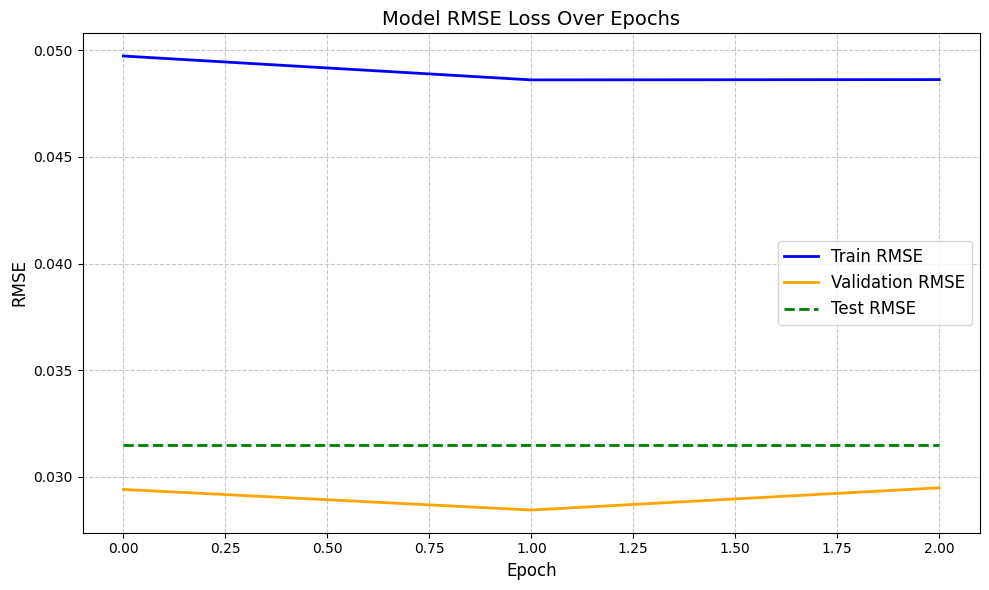

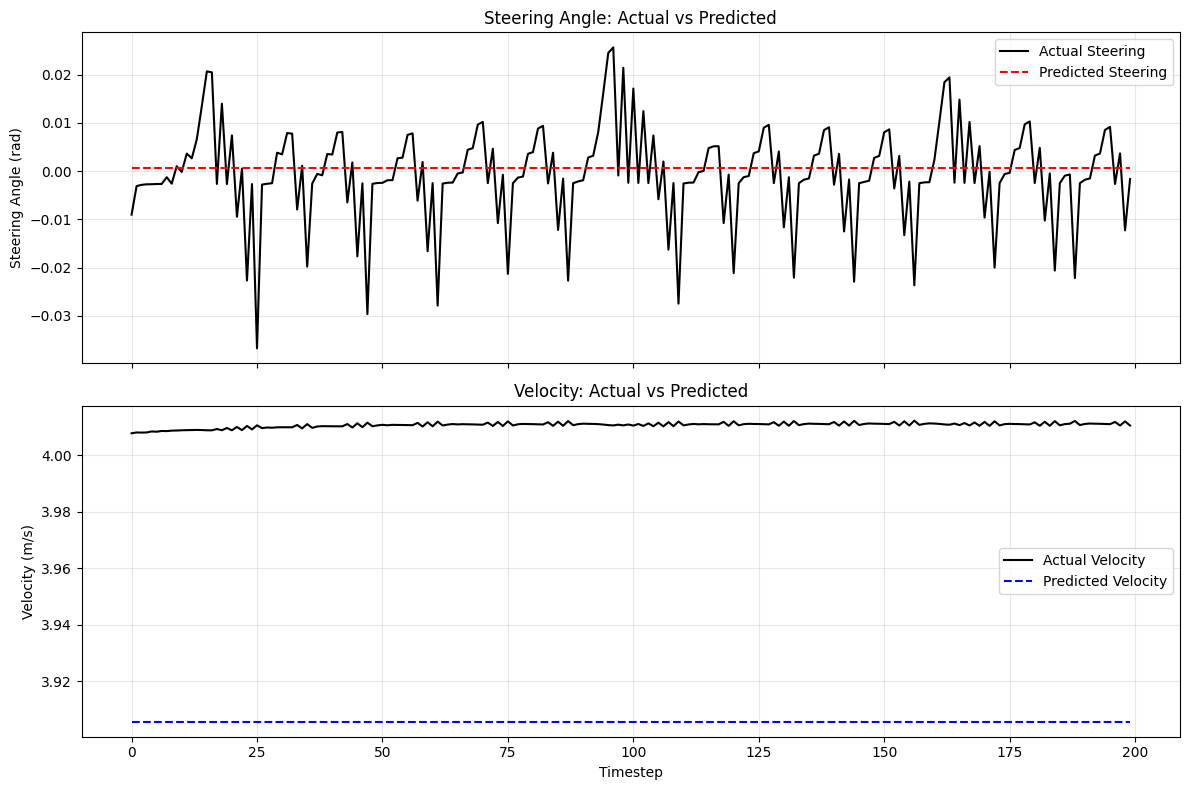

In [25]:
# Example Execution:
plot_learning_curves(history)
plot_predictions_vs_actual(model, test_loader, DEVICE, target_scaler=fitted_target_scaler, num_samples=200)

In [28]:
# Diagnostic: quantify label distribution + naive baselines to explain low loss vs poor steering generalization

from sklearn.metrics import mean_squared_error


def _collect_window_targets(episodes, seq_length, predict_length):
    ys = []
    for ep in episodes:
        T = ep["targets"].shape[0]
        max_start = T - seq_length - predict_length + 1
        if max_start <= 0:
            continue
        for start in range(max_start):
            target_idx = start + seq_length + predict_length - 1
            ys.append(ep["targets"][target_idx])
    return np.array(ys)


def diagnose_targets_and_baselines(pkl_path, seq_length=100, predict_length=1, seed=42):
    with open(pkl_path, "rb") as f:
        episodes = pickle.load(f)

    episodes = [ep for ep in episodes if not ep.get("has_collision", False)]

    # split exactly like training pipeline
    idx = list(range(len(episodes)))
    random.seed(seed)
    random.shuffle(idx)
    episodes = [episodes[i] for i in idx]

    n = len(episodes)
    n_train = int(0.7 * n)
    n_val = int(0.15 * n)
    train_eps = episodes[:n_train]
    test_eps = episodes[n_train + n_val :]

    # raw target distribution
    all_targets = np.concatenate([ep["targets"] for ep in episodes], axis=0)
    steering = all_targets[:, 0]
    velocity = all_targets[:, 1]

    print("=== Raw target distribution ===")
    print(f"steering mean={steering.mean():.6f}, std={steering.std():.6f}, min={steering.min():.6f}, max={steering.max():.6f}")
    print(f"velocity mean={velocity.mean():.6f}, std={velocity.std():.6f}, min={velocity.min():.6f}, max={velocity.max():.6f}")
    for th in [0.005, 0.01, 0.02, 0.05]:
        frac = (np.abs(steering) < th).mean()
        print(f"fraction |steering| < {th:.3f}: {frac:.3f}")

    # fit target scaler on train only (same as pipeline)
    target_scaler = MinMaxScaler()
    train_targets_flat = np.concatenate([ep["targets"] for ep in train_eps], axis=0)
    target_scaler.fit(train_targets_flat)

    # scale targets for baseline comparison in training space
    for ep in train_eps:
        ep["targets_scaled"] = target_scaler.transform(ep["targets"])
    for ep in test_eps:
        ep["targets_scaled"] = target_scaler.transform(ep["targets"])

    def collect_scaled_window_targets(eps):
        ys = []
        for ep in eps:
            T = ep["targets_scaled"].shape[0]
            max_start = T - seq_length - predict_length + 1
            if max_start <= 0:
                continue
            for s in range(max_start):
                t = s + seq_length + predict_length - 1
                ys.append(ep["targets_scaled"][t])
        return np.array(ys)

    y_train = collect_scaled_window_targets(train_eps)
    y_test = collect_scaled_window_targets(test_eps)

    # trivial baselines
    pred_mean = np.repeat(y_train.mean(axis=0, keepdims=True), len(y_test), axis=0)
    pred_zero = np.zeros_like(y_test)

    rmse_mean_scaled = np.sqrt(np.mean((pred_mean - y_test) ** 2, axis=0))
    rmse_zero_scaled = np.sqrt(np.mean((pred_zero - y_test) ** 2, axis=0))

    print("\n=== Trivial baseline RMSE in scaled space [steering, velocity] ===")
    print(f"predict train-mean: {rmse_mean_scaled}")
    print(f"predict all-zeros : {rmse_zero_scaled}")

    # and in physical units
    y_test_phys = target_scaler.inverse_transform(y_test)
    mean_phys = target_scaler.inverse_transform(pred_mean)
    zero_phys = target_scaler.inverse_transform(pred_zero)

    rmse_mean_phys = np.sqrt(np.mean((mean_phys - y_test_phys) ** 2, axis=0))
    rmse_zero_phys = np.sqrt(np.mean((zero_phys - y_test_phys) ** 2, axis=0))

    print("\n=== Trivial baseline RMSE in physical units [steering(rad), velocity(m/s)] ===")
    print(f"predict train-mean: {rmse_mean_phys}")
    print(f"predict all-zeros : {rmse_zero_phys}")


# Run diagnostic
diagnose_targets_and_baselines(PKL_PATH, seq_length=SEQ_LENGTH, predict_length=PREDICT_LENGTH, seed=42)

=== Raw target distribution ===
steering mean=-0.000374, std=0.050936, min=-0.400000, max=0.400000
velocity mean=3.928407, std=0.304506, min=2.000000, max=12.000000
fraction |steering| < 0.005: 0.435
fraction |steering| < 0.010: 0.571
fraction |steering| < 0.020: 0.687
fraction |steering| < 0.050: 0.846

=== Trivial baseline RMSE in scaled space [steering, velocity] ===
predict train-mean: [0.06546752 0.03055692]
predict all-zeros : [0.50378174 0.19533119]

=== Trivial baseline RMSE in physical units [steering(rad), velocity(m/s)] ===
predict train-mean: [0.05237215 0.30581918]
predict all-zeros : [0.4030205 1.9533734]


In [ ]:
# Diagnostic: model behavior by target (not just aggregate loss)

def evaluate_per_target_metrics(model, dataloader, device, target_scaler):
    model.eval()
    preds, actuals = [], []

    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            batch_x = batch_x.to(device)
            out = model(batch_x).cpu().numpy()
            preds.append(out)
            actuals.append(batch_y.numpy())

    preds = np.concatenate(preds, axis=0)
    actuals = np.concatenate(actuals, axis=0)

    # back to physical units
    preds_phys = target_scaler.inverse_transform(preds)
    actuals_phys = target_scaler.inverse_transform(actuals)

    # metrics per target
    names = ["steering(rad)", "velocity(m/s)"]
    print("=== Model architecture sanity check ===")
    print(f"model.model_type stored: {model.model_type}")
    if model.model_type not in ["LSTM", "GRU", "RNN"]:
        print("WARNING: model_type is not one of [LSTM, GRU, RNN]. In this class that falls back to plain RNN.")

    print("\n=== Per-target metrics in physical units ===")
    for i, name in enumerate(names):
        y = actuals_phys[:, i]
        yhat = preds_phys[:, i]
        rmse = np.sqrt(np.mean((yhat - y) ** 2))
        mae = np.mean(np.abs(yhat - y))
        var_y = np.var(y)
        r2 = 1.0 - (np.mean((yhat - y) ** 2) / (var_y + 1e-12))
        print(f"{name}: RMSE={rmse:.6f}, MAE={mae:.6f}, R2={r2:.6f}, pred_std={np.std(yhat):.6f}, true_std={np.std(y):.6f}")

    print("\n=== Collapse check ===")
    steer_pred_std = np.std(preds_phys[:, 0])
    steer_true_std = np.std(actuals_phys[:, 0])
    vel_pred_std = np.std(preds_phys[:, 1])
    vel_true_std = np.std(actuals_phys[:, 1])
    print(f"steering std ratio pred/true: {steer_pred_std / (steer_true_std + 1e-12):.4f}")
    print(f"velocity std ratio pred/true: {vel_pred_std / (vel_true_std + 1e-12):.4f}")


evaluate_per_target_metrics(model, test_loader, DEVICE, fitted_target_scaler)

## Section 6: Model Saving

Save model as a .pkl file or to hugging face or something if good!

Could also allow for future tuning and training

In [26]:

import joblib
import re

def save_model_and_scaler(model, input_scaler, target_scaler, model_name="f1tenth_model"):
    """
    Saves model weights and both input/target scalers to the models directory.
    """
    # Sanitize the model name to create a valid filename
    sanitized_model_name = re.sub(r'[\\/*?:"<>|]', "_", model_name)

    # Define the target directory for models (one level up from the 'notebooks' dir)
    models_dir = os.path.join(os.getcwd(), "..", "models")
    os.makedirs(models_dir, exist_ok=True)

    # Define file paths
    model_save_path = os.path.join(models_dir, f"{sanitized_model_name}.pt")
    input_scaler_path = os.path.join(models_dir, f"{sanitized_model_name}_input_scaler.pkl")
    target_scaler_path = os.path.join(models_dir, f"{sanitized_model_name}_target_scaler.pkl")

    # Save model and scalers
    torch.save(model.state_dict(), model_save_path)
    joblib.dump(input_scaler, input_scaler_path)
    joblib.dump(target_scaler, target_scaler_path)

    print(f"Model weights successfully saved to: {model_save_path}")
    print(f"Input scaler successfully saved to: {input_scaler_path}")
    print(f"Target scaler successfully saved to: {target_scaler_path}")


In [27]:
#Example Execution:
MODEL_NAME = "LSTM_2_layer_512"
save_model_and_scaler(
    model=model,
    input_scaler=fitted_input_scaler,
    target_scaler=fitted_target_scaler,
    model_name=MODEL_NAME
)

# ==========================================
# Example: Loading for Deployment / Fine-Tuning
# ==========================================
# loaded_model = F1TenthSequenceModel(
#     input_dim=63,
#     rnn_hidden_dim=512,
#     output_dim=2,
#     model_type='LSTM',
#     num_rnn_layers=2,
#     use_embedding=False,
#     fc_layer_sizes=[256, 128, 64]
# ).to(DEVICE)
#
# models_dir = os.path.join(os.getcwd(), "..", "models")
# loaded_model.load_state_dict(torch.load(os.path.join(models_dir, f"{MODEL_NAME}.pt"), map_location=DEVICE))
# loaded_model.eval()
#
# loaded_input_scaler = joblib.load(os.path.join(models_dir, f"{MODEL_NAME}_input_scaler.pkl"))
# loaded_target_scaler = joblib.load(os.path.join(models_dir, f"{MODEL_NAME}_target_scaler.pkl"))

Model weights successfully saved to: /home/devin_work/work/f1tenth/ApproxiMPC/notebooks/../models/LSTM_2_layer_512.pt
Input scaler successfully saved to: /home/devin_work/work/f1tenth/ApproxiMPC/notebooks/../models/LSTM_2_layer_512_input_scaler.pkl
Target scaler successfully saved to: /home/devin_work/work/f1tenth/ApproxiMPC/notebooks/../models/LSTM_2_layer_512_target_scaler.pkl
